In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

In [3]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    # Estraiamo tutti i concetti unici per mapparli ad un ID numerico
    concepts = set()
    for item in data:
        concepts.add(item[0]) # concept_i
        concepts.add(item[1]) # concept_j
        
    concept2id = {c: idx for idx, c in enumerate(list(concepts))}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [4]:
dataset, concept2id, id2concept = load_data(JSON_PATH)

In [5]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

model = BoxHierarchyModel(num_concepts=len(concept2id), dim=32)
optimizer = Adam(model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

AllenNLP not available. Registrable won't work.


In [6]:
train(model, optimizer, criterion, dataset, concept2id, id2concept)

Trovati 50 concetti unici e 583 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 1.4355
Epoca [10/100] | Loss: 0.1846
Epoca [20/100] | Loss: 0.0537
Epoca [30/100] | Loss: 0.0200
Epoca [40/100] | Loss: 0.0099
Epoca [50/100] | Loss: 0.0060
Epoca [60/100] | Loss: 0.0046
Epoca [70/100] | Loss: 0.0037
Epoca [80/100] | Loss: 0.0033
Epoca [90/100] | Loss: 0.0030
Epoca [100/100] | Loss: 0.0027

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | arm
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: lower_body_part | big
 - P_teorica: 0.0 -> P_predetta: 0.0033
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0000


In [ ]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

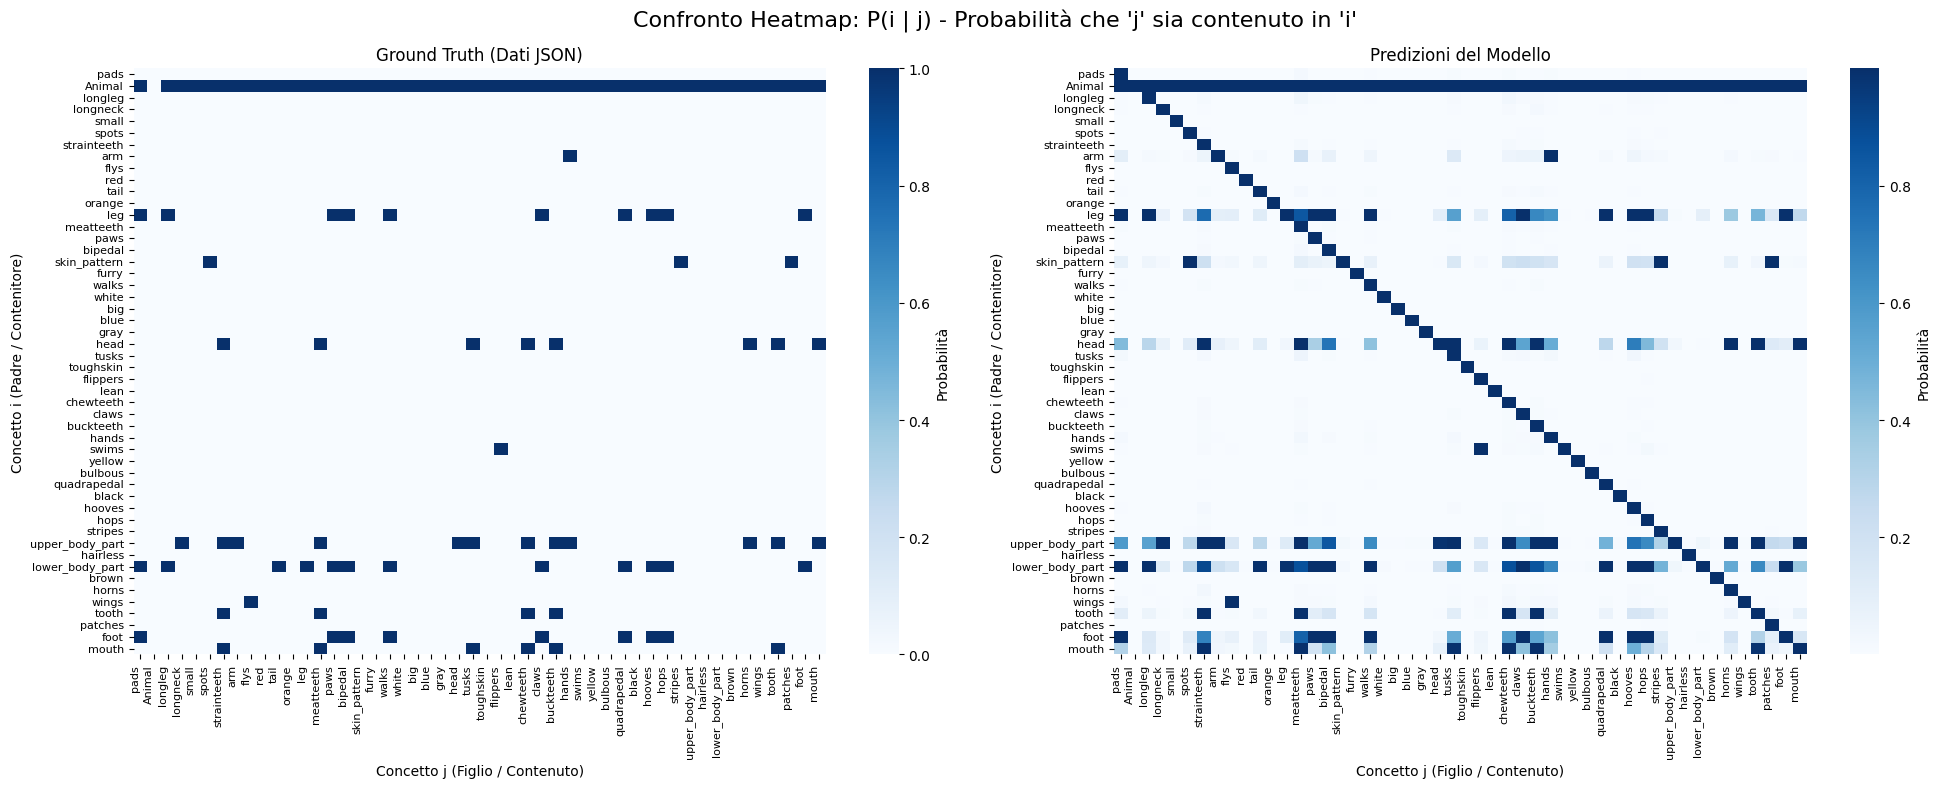

In [8]:
visualize_heatmap_compare(model, dataset, concept2id, id2concept)

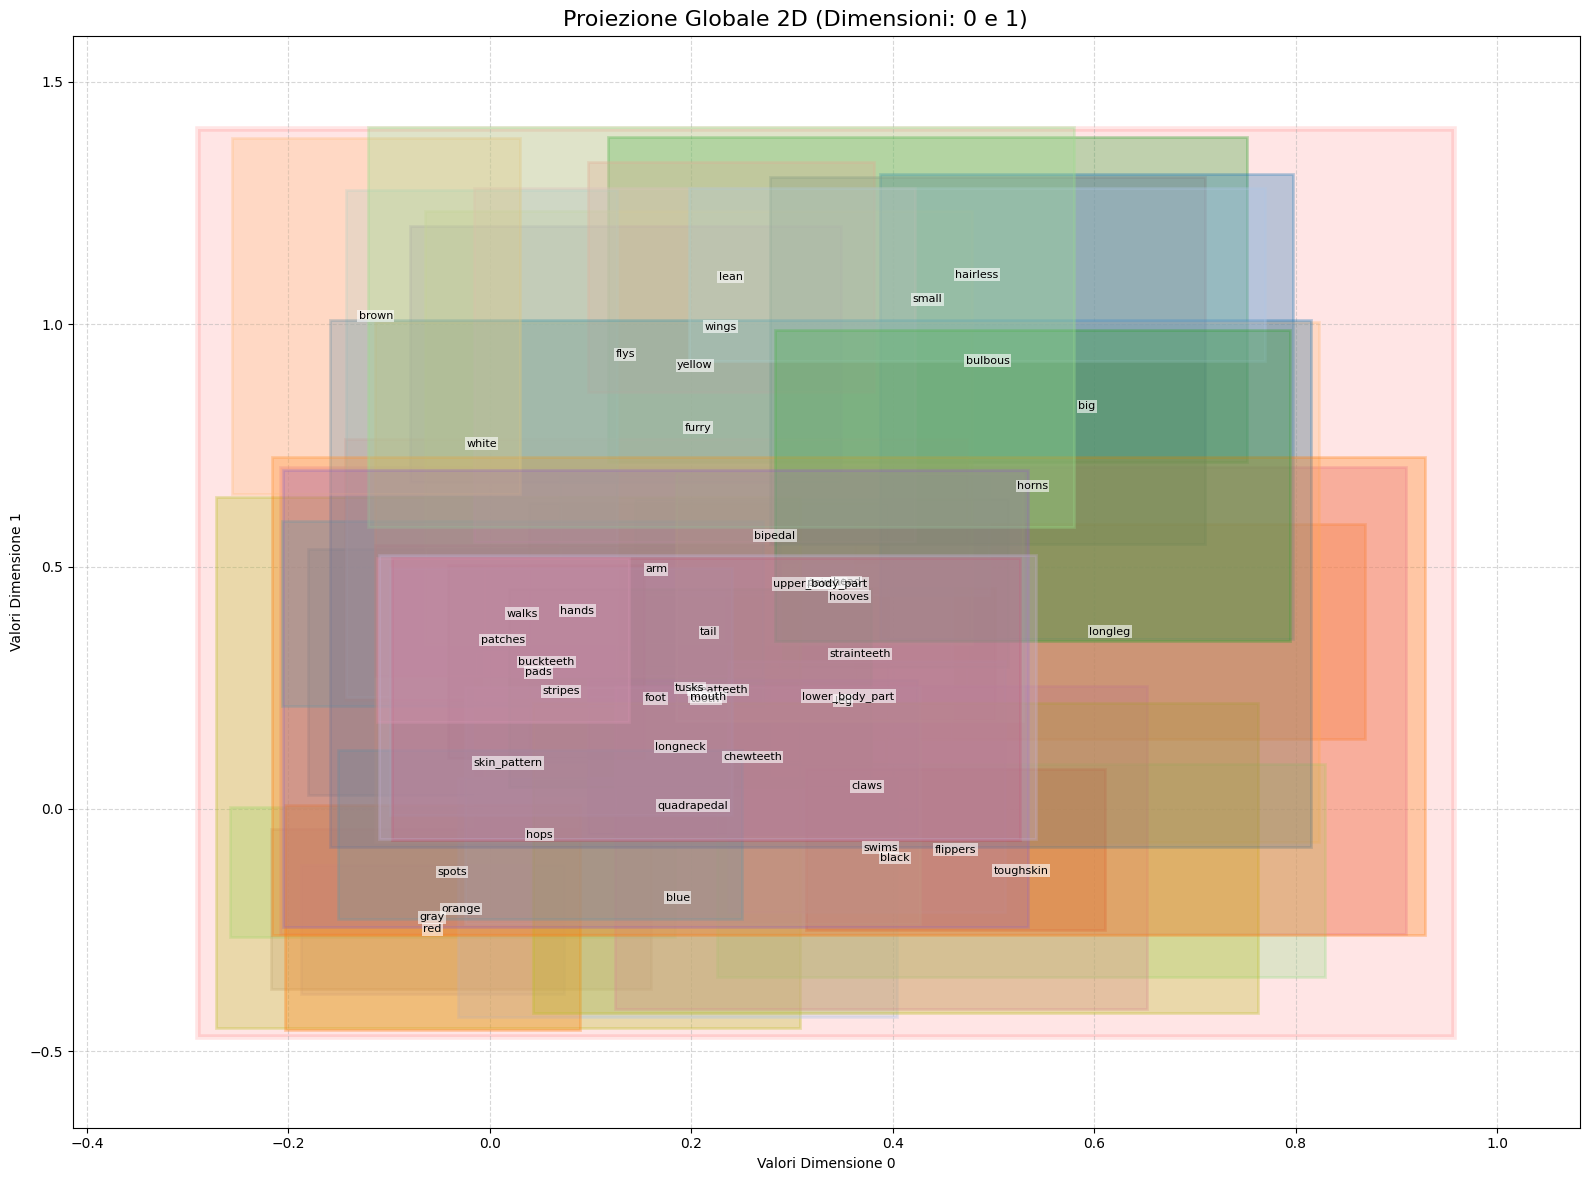

In [9]:
visualize_all_boxes_2d(model, id2concept, dim_x=0, dim_y=1)

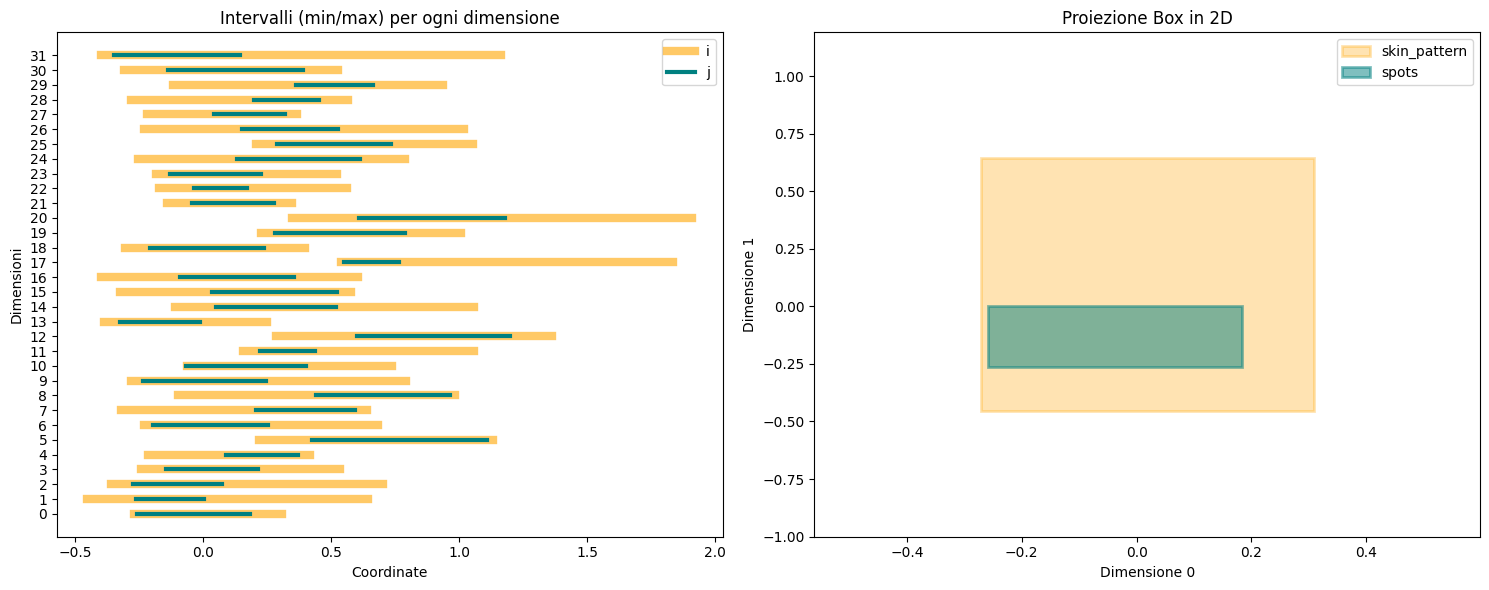

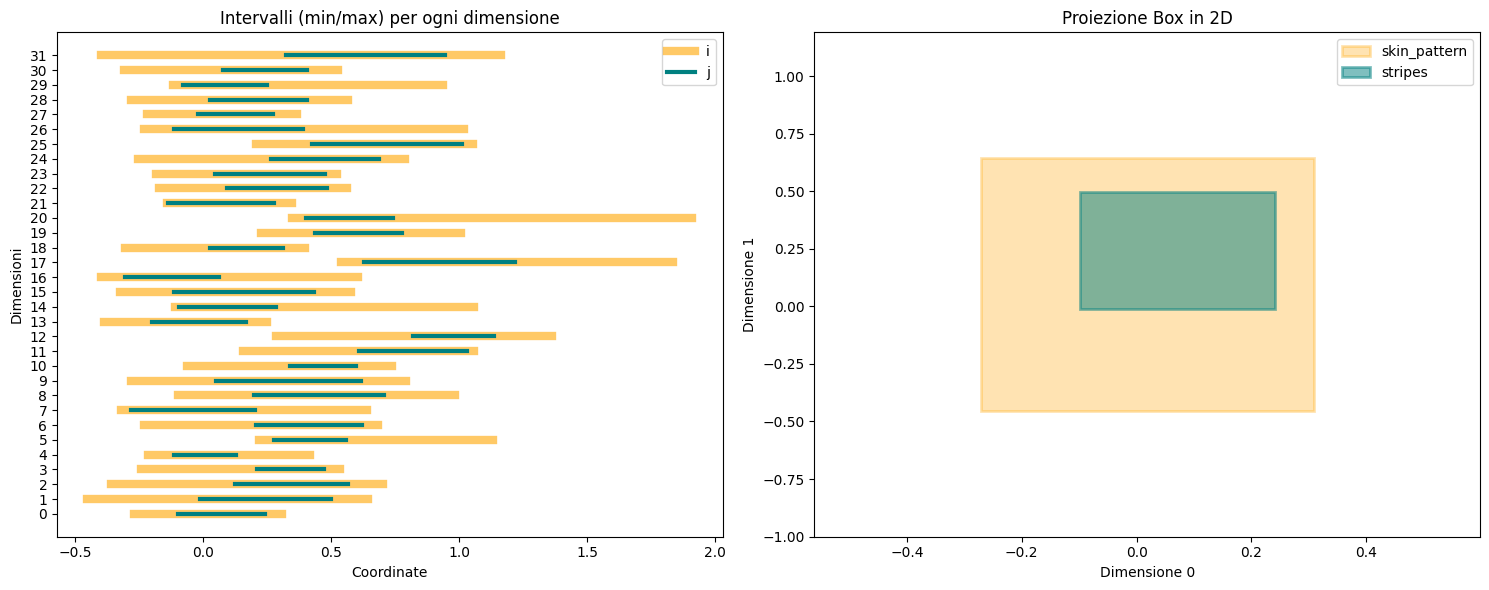

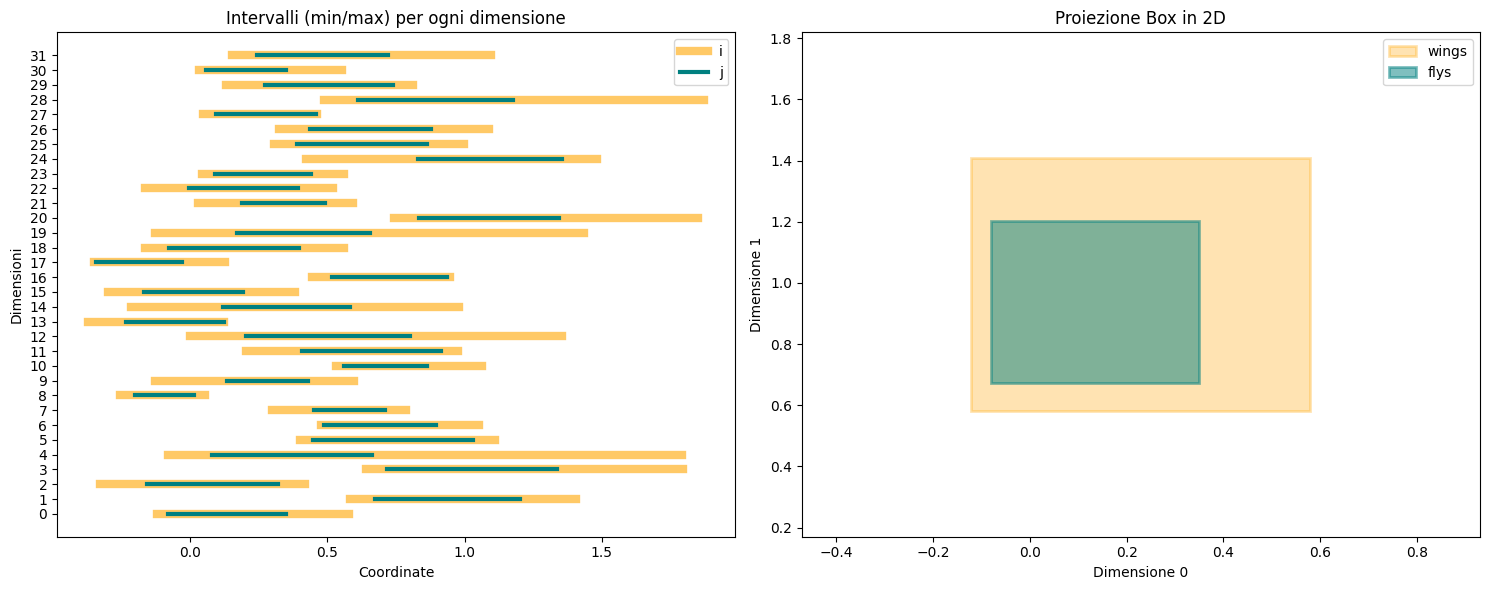

In [12]:
visualize_concept_hierarchy(model, id2concept, concept2id, "skin_pattern", "spots")
visualize_concept_hierarchy(model, id2concept, concept2id, "skin_pattern", "stripes")
visualize_concept_hierarchy(model, id2concept, concept2id, "wings", "flys")